## Import das bibliotecas

In [1]:
import torch
from torch import nn
from torch.utils.data import Dataset
from torchvision.transforms import v2
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split
import torchvision.models as models
import sklearn.metrics as metrics
import matplotlib.pyplot as plt
import optuna
from fvcore.nn import FlopCountAnalysis
from plotly.io import show
import os
from PIL import Image
import json
import pickle
from pathlib import Path
from datetime import datetime

### Configurando variáveis de ambiente e execução

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


In [3]:
NUM_WORKERS = 2
PERSISTENT_WORKERS = True
NJOBS = 1
NUM_TRIALS = 200
DIFF_THRESHOLD = 0.0

# === Persistência do Optuna ===
STUDY_NAME = "raabin_wbc_cnn_optimization"
STORAGE_DIR = Path("./optuna_studies")
STORAGE_DIR.mkdir(exist_ok=True)
DATABASE_PATH = f"sqlite:///{STORAGE_DIR}/optuna_study.db"
MODELS_DIR = STORAGE_DIR / "models"
MODELS_DIR.mkdir(exist_ok=True)
RESUME_STUDY = False  # Set to False se quiser começar novo estudo
LOGS_FILE = STORAGE_DIR / "trials_log.json"

In [4]:
# Reproducibility
SEED = 26
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

import numpy as np
import random
np.random.seed(SEED)
random.seed(SEED)

## Preparação do dataset

### Funções de carregamento, split, e plot

In [5]:
CLASSES_DO_PROJETO = ['Basophil', 'Eosinophil', 'Lymphocyte', 'Monocyte', 'Neutrophil']
MEAN = torch.tensor([0.7052, 0.5395, 0.5889])
STD = torch.tensor([0.1625, 0.1903, 0.0974])
transform_train = v2.Compose([v2.ToImage(),
                              v2.ToDtype(dtype=torch.float32, scale=True),
                              v2.Normalize(mean=MEAN, std=STD)])
transform_test = v2.Compose([v2.ToImage(),
                             v2.ToDtype(dtype=torch.float32, scale=True),
                             v2.Normalize(mean=MEAN, std=STD)])

In [6]:
from dataset_utils import RaabinDataset

In [7]:
from dataset_utils import RaabinDataset


def split_train_val_dataset(dataset, val_size, random_state=42):
    labels = np.asarray([target for _, target in dataset.samples], dtype=np.int64)
    indices = np.arange(len(dataset.samples))
    train_idx, val_idx = train_test_split(
        indices, 
        test_size=val_size, 
        random_state=random_state, 
        stratify=labels)
    return Subset(dataset, train_idx), Subset(dataset, val_idx)

In [8]:
def calcular_media_std(loader):
    channels_sum, channels_squared_sum, num_batches = 0, 0, 0
    
    for data, _ in loader:
        channels_sum += torch.mean(data, dim=[0, 2, 3])
        channels_squared_sum += torch.mean(data ** 2, dim=[0, 2, 3])
        num_batches += 1
        
    mean = channels_sum / num_batches
    std = (channels_squared_sum / num_batches - mean ** 2) ** 0.5
    return mean, std


In [9]:
def denormalize_image(img):
    mean = MEAN.to(img.device).view(3, 1, 1)
    std = STD.to(img.device).view(3, 1, 1)
    return img * std + mean

In [10]:
def plot_images(data, class_names=None, undo_norm=True):
    img, label = data

    if undo_norm:
        img = denormalize_image(img)

    img = img.detach().cpu().permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)

    label_idx = int(label.item()) if torch.is_tensor(label) else int(label)
    if class_names is not None:
        title = class_names[label_idx]
    else:
        title = str(label_idx)

    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.title(f"Label: {title}")
    plt.axis("off")
    plt.show()


### execução

In [11]:
train_dataset = RaabinDataset(root_dir='./../datasets/raabin_wbc/Train', class_list=CLASSES_DO_PROJETO, transform=transform_train)
testA_dataset = RaabinDataset(root_dir='./../datasets/raabin_wbc/Test-A', class_list=CLASSES_DO_PROJETO, transform=transform_test)
testB_dataset = RaabinDataset(root_dir='./../datasets/raabin_wbc/Test-B', class_list=CLASSES_DO_PROJETO, transform=transform_test)

In [12]:
print(f'Tamanho do dataset de treino: {len(train_dataset)} amostras')
print(f'Tamanho do dataset de teste A: {len(testA_dataset)} amostras')
print(f'Tamanho do dataset de teste B: {len(testB_dataset)} amostras')

Tamanho do dataset de treino: 10175 amostras
Tamanho do dataset de teste A: 4339 amostras
Tamanho do dataset de teste B: 2119 amostras


In [13]:
train_split_dataset, val_dataset = split_train_val_dataset(train_dataset, val_size=(3175/10175), random_state=SEED)
print(f'Tamanho do dataset de treino após split: {len(train_split_dataset)} amostras')
print(f'Tamanho do dataset de validação: {len(val_dataset)} amostras')

Tamanho do dataset de treino após split: 6999 amostras
Tamanho do dataset de validação: 3176 amostras


In [14]:
IMG_HEIGHT = train_split_dataset[0][0].shape[1]
IMG_WIDTH = train_split_dataset[0][0].shape[2]
print(f'Tamanho das imagens: {IMG_HEIGHT}x{IMG_WIDTH}')

Tamanho das imagens: 575x575


In [15]:
temp_loader = DataLoader(train_split_dataset, batch_size=64, shuffle=False)

In [16]:
resultado = calcular_media_std(temp_loader)
print(f"Média: {resultado[0]}, DP: {resultado[1]}")

Média: tensor([-0.0055, -0.0020, -0.0031]), DP: tensor([0.9990, 0.9981, 0.9974])


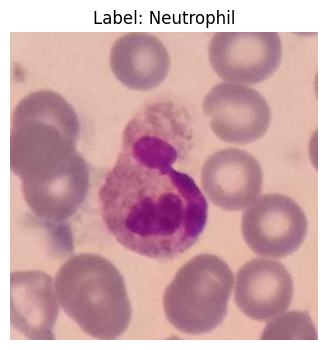

In [17]:
plot_images(train_split_dataset[0], class_names=CLASSES_DO_PROJETO, undo_norm=True)

## EDA

## Códigos para treinamento, avaliação e plot

In [18]:
# função para avaliar o modelo no conjunto de teste
def evaluate_model(model, test_dataloader, metric_fn=metrics.mean_absolute_error, device=device):
    model.eval()
    y = []
    y_pred = []
    with torch.no_grad():
        for X_batch, y_batch in test_dataloader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            outputs = model(X_batch)
            y.extend(y_batch.detach().cpu().tolist())
            y_pred.extend(outputs.detach().cpu().tolist())
    metric_val = metric_fn(y, y_pred)
    return metric_val

In [19]:
# função para treinar o modelo, recebe como entrada o modelo, os dataloaders de treino e validação, a função de perda, o otimizador e o número de épocas e o critério de parada
# a função também salva o histórico da função de perda para treino e validação
def train_model(model, train_dataloader, val_dataloader, loss_fn, optimizer, num_epochs, patience, metric_fn=None, device=device, verbose=False):
    best_val_loss = float('inf')
    epochs_without_improvement = 0
    history_train_loss = []
    history_val_loss = []
    history_val_metric = []

    for epoch in range(num_epochs):
        model.train()
        total_loss = 0

        for X_batch, y_batch in train_dataloader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = loss_fn(outputs, y_batch)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg_train_loss = total_loss / len(train_dataloader)
        history_train_loss.append(avg_train_loss)

        if verbose and epoch % 5 == 0:
            print(f'Epoch {epoch+1}/{num_epochs}, Train Loss: {avg_train_loss:.4f}')

        # validação
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for X_batch, y_batch in val_dataloader:
                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)
                outputs = model(X_batch)
                loss = loss_fn(outputs, y_batch)
                val_loss += loss.item()

        avg_val_loss = val_loss / len(val_dataloader)
        history_val_loss.append(avg_val_loss)

        if verbose and epoch % 5 == 0:
            print(f'Epoch {epoch+1}/{num_epochs}, Validation Loss: {avg_val_loss:.4f}')

        # avaliando a métrica de validação
        if metric_fn is not None:
            metric_val = evaluate_model(model, val_dataloader, metric_fn=metric_fn, device=device)
            history_val_metric.append(metric_val)
            if verbose and epoch % 5 == 0:
                print(f'Epoch {epoch+1}/{num_epochs}, Validation Metric: {metric_val:.4f}')

        # critério de parada
        if (avg_val_loss + DIFF_THRESHOLD) < best_val_loss:
            best_val_loss = avg_val_loss
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            break

    return history_train_loss, history_val_loss, history_val_metric

In [20]:
def plot_loss_graph(history_train_loss, history_val_loss, history_val_metric):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(history_train_loss, label='Train Loss')
    ax1.plot(history_val_loss, label='Val Loss')
    ax1.set_xlabel('Epochs'); ax1.set_ylabel('Loss')
    ax1.set_title('Loss'); ax1.legend()

    if history_val_metric:
        ax2.plot(history_val_metric, label='Val MAE', color='green')
        ax2.set_xlabel('Epochs'); ax2.set_ylabel('MAE')
        ax2.set_title('Validation MAE'); ax2.legend()
    plt.tight_layout(); plt.show()

## CNN

### Funções para criação da CNN

In [21]:
map_activation_functions = {
    'relu': nn.ReLU,
    'sigmoid': nn.Sigmoid,
    'tanh': nn.Tanh,
    'leaky_relu': nn.LeakyReLU,
}
map_optimizers = {
    'adam': torch.optim.Adam,
    'sgd': torch.optim.SGD,
    'rmsprop': torch.optim.RMSprop,
    'adagrad': torch.optim.Adagrad
}
def get_activation_function(name):
    return map_activation_functions[name]()

In [22]:
class CNNParameters:
    def __init__(self, num_conv_layers, stride_conv_layers, input_channels, out_channels_list, use_pooling,
                 padding_conv_layer, dilatation, bias, kernel_size, kernel_stride,
                 kernel_padding, kernel_dilatation, activation_function_conv, fully_connected_layers_list,
                 activation_function_fully_connected, dropout_rate_fully_connected, dropout_rate_conv, output_size_fully_connected,
                 image_size_height, image_size_width, use_normalization_cnn, use_normalization_fc
                 ):
        
        # cnn parameters
        self.num_conv_layers = num_conv_layers
        self.stride_conv_layers = stride_conv_layers
        self.input_channels = input_channels
        self.out_channels_list = out_channels_list
        self.dropout_rate_conv = dropout_rate_conv
        self.padding_conv_layer = padding_conv_layer
        self.dilatation = dilatation
        self.bias = bias
        self.activation_function_conv = activation_function_conv
        self.use_normalization = use_normalization_cnn

        # polling parameters
        self.use_pooling = use_pooling
        self.kernel_size = kernel_size
        self.kernel_stride = kernel_stride
        self.kernel_padding = kernel_padding
        self.kernel_dilatation = kernel_dilatation

        # fully connected layers parameters
        self.fully_connected_layers_list = fully_connected_layers_list
        self.activation_function_fully_connected = activation_function_fully_connected
        self.dropout_rate_fully_connected = dropout_rate_fully_connected
        self.output_size_fully_connected = output_size_fully_connected
        self.use_normalization_fc = use_normalization_fc
        

        #flatten size
        self.image_size_height = image_size_height
        self.image_size_width = image_size_width
        self.image_size_height_output = 0
        self.image_size_width_output = 0
        self.image_size_height_output, self.image_size_width_output = self._calculate_output_size(image_size_height, image_size_width)
        self.flatten_size = self.image_size_height_output * self.image_size_width_output * self.out_channels_list[-1]

    def _calculate_output_size(self, input_size_height, input_size_width):
        output_size_height = input_size_height
        output_size_width = input_size_width
        for i in range(self.num_conv_layers):
            output_size_height = (output_size_height + 2 * self.padding_conv_layer - self.dilatation * (self.kernel_size - 1) - 1) // self.stride_conv_layers + 1
            output_size_width = (output_size_width + 2 * self.padding_conv_layer - self.dilatation * (self.kernel_size - 1) - 1) // self.stride_conv_layers + 1
            if self.use_pooling:
                output_size_height = (output_size_height + 2 * self.kernel_padding - self.kernel_dilatation * (self.kernel_size - 1) - 1) // self.kernel_stride + 1
                output_size_width = (output_size_width + 2 * self.kernel_padding - self.kernel_dilatation * (self.kernel_size - 1) - 1) // self.kernel_stride + 1
        return output_size_height, output_size_width

In [23]:
class CNN(nn.Module):
    def __init__(self, cnn_parameters: CNNParameters):
        super(CNN, self).__init__()
        self.cnn_parameters = cnn_parameters

        layers = []

        for i in range(self.cnn_parameters.num_conv_layers):
            layers.append(nn.Conv2d(in_channels=self.cnn_parameters.input_channels if i == 0 else self.cnn_parameters.out_channels_list[i-1],
                                    out_channels=self.cnn_parameters.out_channels_list[i],
                                    kernel_size=self.cnn_parameters.kernel_size,
                                    stride=self.cnn_parameters.stride_conv_layers,
                                    padding=self.cnn_parameters.padding_conv_layer,
                                    dilation=self.cnn_parameters.dilatation,
                                    bias=self.cnn_parameters.bias))
            layers.append(get_activation_function(self.cnn_parameters.activation_function_conv))

            if self.cnn_parameters.use_normalization:
                layers.append(nn.BatchNorm2d(self.cnn_parameters.out_channels_list[i], device=device))

            if self.cnn_parameters.dropout_rate_conv > 0:
                layers.append(nn.Dropout2d(self.cnn_parameters.dropout_rate_conv))

            if self.cnn_parameters.use_pooling:
                layers.append(nn.MaxPool2d(kernel_size=self.cnn_parameters.kernel_size,
                                           stride=self.cnn_parameters.kernel_stride,
                                           padding=self.cnn_parameters.kernel_padding,
                                           dilation=self.cnn_parameters.kernel_dilatation))
        
        self.conv_layers = nn.Sequential(*layers)
        
        fully_connected_layers = []
        input_size_fully_connected = cnn_parameters.flatten_size

        for output_size in self.cnn_parameters.fully_connected_layers_list:
            fully_connected_layers.append(nn.Linear(input_size_fully_connected, output_size))
            fully_connected_layers.append(get_activation_function(self.cnn_parameters.activation_function_fully_connected))
            if self.cnn_parameters.use_normalization_fc:
                fully_connected_layers.append(nn.BatchNorm1d(output_size, device=device))
            if self.cnn_parameters.dropout_rate_fully_connected > 0:
                fully_connected_layers.append(nn.Dropout(self.cnn_parameters.dropout_rate_fully_connected))
            input_size_fully_connected = output_size
        
        fully_connected_layers.append(nn.Linear(input_size_fully_connected, self.cnn_parameters.output_size_fully_connected))
        self.fully_connected_layers = nn.Sequential(*fully_connected_layers)

    def forward(self, x):
        x = self.conv_layers(x)
        x = x.flatten(start_dim=1)
        x = self.fully_connected_layers(x)
        return x
            
        

In [24]:
def get_or_create_study(study_name, storage_db, resume=True, seed=None):
    """
    Carrega um estudo existente ou cria um novo.
    
    Args:
        study_name: Nome único do estudo
        storage_db: URL do banco SQLite (ex: sqlite:///path/study.db)
        resume: Se True, retoma estudo existente; se False, cria novo
        seed: Seed para TPE sampler
    
    Returns:
        study: Optuna Study object
    """
    sampler = optuna.samplers.TPESampler(seed=seed)
    
    try:
        # Tenta carregar estudo existente
        study = optuna.load_study(
            study_name=study_name,
            storage=storage_db,
            sampler=sampler
        )
        if resume:
            print(f"✓ Estudo '{study_name}' carregado. Trials completados: {len(study.trials)}")
            return study
        else:
            # Se resume=False, apagar e criar novo
            optuna.delete_study(study_name=study_name, storage=storage_db)
            print(f"✓ Estudo anterior deletado. Criando novo.")
    except:
        pass
    
    # Criar novo estudo
    study = optuna.create_study(
        study_name=study_name,
        storage=storage_db,
        directions=['maximize', 'minimize'],
        sampler=sampler,
        load_if_exists=True
    )
    print(f"✓ Novo estudo '{study_name}' criado")
    return study

def log_trial_result(trial_number, trial_params, f1_score, flops, trial_exception=None):
    """Salva resultado de cada trial em JSON para auditoria."""
    try:
        if LOGS_FILE.exists():
            with open(LOGS_FILE, 'r') as f:
                logs = json.load(f)
        else:
            logs = []
        
        trial_log = {
            "trial_id": trial_number,
            "timestamp": datetime.now().isoformat(),
            "f1_score": float(f1_score) if f1_score is not None else None,
            "flops": float(flops) if flops != float('inf') else "inf",
            "exception": str(trial_exception) if trial_exception else None,
            "hyperparams": trial_params
        }
        logs.append(trial_log)
        
        with open(LOGS_FILE, 'w') as f:
            json.dump(logs, f, indent=2)
    except Exception as e:
        print(f"Erro ao salvar log de trial: {e}")

def save_trial_model(trial, model, cnn_params):
    """Salva modelo de um trial bem-sucedido."""
    try:
        model_file = MODELS_DIR / f"trial_{trial.number}_model.pth"
        torch.save({
            'model_state_dict': model.state_dict(),
            'trial_number': trial.number,
            'cnn_params': {
                'num_conv_layers': cnn_params.num_conv_layers,
                'out_channels_list': cnn_params.out_channels_list,
                'kernel_size': cnn_params.kernel_size,
                'activation_function_conv': cnn_params.activation_function_conv,
                'activation_function_fc': cnn_params.activation_function_fully_connected,
                'output_size': cnn_params.output_size_fully_connected,
            },
            'timestamp': datetime.now().isoformat()
        }, model_file)
        print(f"  → Modelo salvo: {model_file}")
    except Exception as e:
        print(f"  ⚠ Erro ao salvar modelo: {e}")

def print_study_summary():
    """Imprime resumo dos trials completados."""
    study = optuna.load_study(
        study_name=STUDY_NAME,
        storage=DATABASE_PATH
    )
    
    print(f"\n{'='*60}")
    print(f"RESUMO DO ESTUDO: {STUDY_NAME}")
    print(f"{'='*60}")
    print(f"Total de trials: {len(study.trials)}")
    print(f"Trials completos: {len([t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE])}")
    print(f"Trials falhados: {len([t for t in study.trials if t.state == optuna.trial.TrialState.FAIL])}")
    
    best_trial = study.best_trial
    if best_trial:
        print(f"\nMelhor trial (por F1-Score):")
        print(f"  Trial ID: {best_trial.number}")
        print(f"  F1-Score: {best_trial.values[0]:.4f}")
        print(f"  FLOPs: {best_trial.values[1]:.2e}")
        print(f"\n  Hiperparâmetros:")
        for key, value in best_trial.params.items():
            print(f"    {key}: {value}")
    print(f"{'='*60}\n")

In [25]:
def create_cnn_model_and_dataloaders(cnn_parameters, train_data, test_data, val_data, batch_size):
    model = CNN(cnn_parameters)
    
    # Validar e configurar workers
    num_workers = NUM_WORKERS if NUM_WORKERS > 0 else 0
    persistent_workers = PERSISTENT_WORKERS if num_workers > 0 else False
    
    kwargs = dict(
        batch_size=batch_size,
        num_workers=num_workers,
        pin_memory=(device.type == "cuda")
    )
    
    if persistent_workers:
        kwargs['persistent_workers'] = True
        kwargs['prefetch_factor'] = 2
    
    train_dataloader = DataLoader(train_data, shuffle=True, **kwargs)
    test_dataloader = DataLoader(test_data, shuffle=False, **kwargs)
    val_dataloader = DataLoader(val_data, shuffle=False, **kwargs)
    
    return model, train_dataloader, test_dataloader, val_dataloader

In [26]:
def objective(trial):
    """
    Otimização com persistência de modelos e limpeza de memória.
    """
    try:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

        num_conv_layers = trial.suggest_int('num_conv_layers', 1, 5)
        
        out_channels_list = []
        for i in range(num_conv_layers):
            out_channels = trial.suggest_categorical(f'out_channels_layer_{i}', [8, 16, 32, 64, 128])
            out_channels_list.append(out_channels)

        kernel_size = trial.suggest_int('kernel_size', 3, 5)
        stride_conv = trial.suggest_categorical('stride_conv', [1, 2])
        padding_conv = trial.suggest_categorical('padding_conv', [0, 1, 2, 3, 4])
        dilatation = trial.suggest_categorical('dilatation', [1, 2, 3])
        bias = True

        use_pooling = trial.suggest_categorical('use_pooling', [True, False])
        kernel_stride_pool = trial.suggest_categorical('kernel_stride_pool', [1, 2, 3])
        kernel_padding_pool = 0
        kernel_dilatation_pool = 1

        activation_function_conv = trial.suggest_categorical('activation_function_conv', ['relu', 'leaky_relu', 'tanh'])
        use_dropout_conv = trial.suggest_categorical('use_dropout_conv', [True, False])
        dropout_rate_conv = trial.suggest_categorical('dropout_rate_conv', [0.2, 0.3, 0.4, 0.5, 0.6]) if use_dropout_conv else 0.0

        use_normalization_conv = trial.suggest_categorical('use_normalization_conv', [True, False])

        num_fc_layers = trial.suggest_int('num_fc_layers', 1, 3)
        fully_connected_layers_list = []
        for i in range(num_fc_layers):
            fc_units = trial.suggest_categorical(f'fc_units_{i}', [8, 16, 32, 64, 128, 256])
            fully_connected_layers_list.append(fc_units)

        activation_function_fc = trial.suggest_categorical('activation_function_fc', ['relu', 'leaky_relu', 'tanh', 'sigmoid'])
        use_dropout_fc = trial.suggest_categorical('use_dropout_fc', [True, False])
        dropout_rate_fc = trial.suggest_categorical('dropout_rate_fc', [0.2, 0.3, 0.4, 0.5, 0.6]) if use_dropout_fc else 0.0

        use_normalization_fc = trial.suggest_categorical('use_normalization_fc', [True, False])

        batch_size = trial.suggest_categorical('batch_size', [32, 64, 128, 256])
        learning_rate = trial.suggest_float('learning_rate', 1e-4, 5e-2, log=True)
        optimizer_name = trial.suggest_categorical('optimizer', ['adam', 'sgd', 'rmsprop'])
        use_weight_decay = trial.suggest_categorical('use_weight_decay', [True, False])
        weight_decay = trial.suggest_float('weight_decay', 1e-6, 1e-3, log=True) if use_weight_decay else 0.0

        num_epochs = 100000
        patience = 15

        image_size_height = IMG_HEIGHT
        image_size_width = IMG_WIDTH
        cnn_params = CNNParameters(
            num_conv_layers=num_conv_layers,
            stride_conv_layers=stride_conv,
            input_channels=3,
            out_channels_list=out_channels_list,
            use_pooling=use_pooling,
            padding_conv_layer=padding_conv,
            dilatation=dilatation,
            bias=bias,
            kernel_size=kernel_size,
            kernel_stride=kernel_stride_pool,
            kernel_padding=kernel_padding_pool,
            kernel_dilatation=kernel_dilatation_pool,
            activation_function_conv=activation_function_conv,
            fully_connected_layers_list=fully_connected_layers_list,
            activation_function_fully_connected=activation_function_fc,
            dropout_rate_fully_connected=dropout_rate_fc,
            dropout_rate_conv=dropout_rate_conv,
            output_size_fully_connected=len(CLASSES_DO_PROJETO),
            image_size_height=image_size_height,
            image_size_width=image_size_width,
            use_normalization_cnn=use_normalization_conv,
            use_normalization_fc=use_normalization_fc
        )

        if cnn_params.image_size_height_output <= 0 or cnn_params.image_size_width_output <= 0:
            return 0.0, float('inf')

        model, train_dataloader, test_dataloader, val_dataloader = create_cnn_model_and_dataloaders(
            cnn_params, train_split_dataset, testA_dataset, val_dataset, batch_size
        )
        model = model.to(device)

        loss_fn = nn.CrossEntropyLoss()
        optimizer_cls = map_optimizers[optimizer_name]

        if optimizer_name == 'sgd':
            use_momentum = trial.suggest_categorical('use_momentum', [True, False])
            momentum = trial.suggest_float('momentum', 0.5, 0.9) if use_momentum else 0.0
            use_nesterov = trial.suggest_categorical('use_nesterov', [True, False]) if use_momentum else False
            optimizer = optimizer_cls(model.parameters(), lr=learning_rate, momentum=momentum, weight_decay=weight_decay, nesterov=use_nesterov)
        elif optimizer_name == 'adam':
            use_betas = trial.suggest_categorical('use_betas', [True, False])
            if use_betas:
                beta1 = trial.suggest_float('beta1', 0.8, 0.99)
                beta2 = trial.suggest_float('beta2', 0.9, 0.999)
                optimizer = optimizer_cls(model.parameters(), lr=learning_rate, weight_decay=weight_decay, betas=(beta1, beta2))
            else:
                optimizer = optimizer_cls(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
        else:  # rmsprop
            use_momentum = trial.suggest_categorical('use_momentum', [True, False])
            momentum = trial.suggest_float('momentum', 0.5, 0.9) if use_momentum else 0.0
            optimizer = optimizer_cls(model.parameters(), lr=learning_rate, weight_decay=weight_decay, momentum=momentum)

        history_train_loss, history_val_loss, history_val_metric = train_model(
            model,
            train_dataloader,
            val_dataloader,
            loss_fn,
            optimizer,
            num_epochs=num_epochs,
            patience=patience,
            metric_fn=metrics.accuracy_score,  # CORRIGIDO: usar accuracy_score para classificação
            device=device,
        )

        eval_metric = evaluate_model(model, val_dataloader, metric_fn=metrics.accuracy_score, device=device)
        flops = FlopCountAnalysis(model.cpu(), torch.randn(1, 3, IMG_HEIGHT, IMG_WIDTH).cpu()).total()

        # === NOVO: Salvar modelo e log ===
        save_trial_model(trial, model, cnn_params)
        log_trial_result(trial.number, trial.params, eval_metric, flops)
        
        # Limpeza de memória
        del model, train_dataloader, val_dataloader, test_dataloader, optimizer
        if device.type == 'cuda':
            torch.cuda.empty_cache()

        return eval_metric, flops

    except Exception as e:
        print(f"Erro durante trial {trial.number}: {e}")
        log_trial_result(trial.number, {}, None, float('inf'), trial_exception=e)
        return 0.0, float('inf')

### execução

In [ ]:
# === Carregamento ou Criação do Estudo ===
study = get_or_create_study(
    study_name=STUDY_NAME,
    storage_db=DATABASE_PATH,
    resume=RESUME_STUDY,
    seed=SEED
)

print(f"\nIniciando otimização com {NUM_TRIALS} trials...\n")

# Executar otimização
study.optimize(objective, n_trials=NUM_TRIALS)

# Resumo final
print_study_summary()

[I 2026-05-30 22:21:30,814] A new study created in RDB with name: raabin_wbc_cnn_optimization


✓ Estudo anterior deletado. Criando novo.
✓ Novo estudo 'raabin_wbc_cnn_optimization' criado

Iniciando otimização com 200 trials...

